In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('IVV ETF Stock Price History.csv')
df = df.dropna()
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,01/03/2022,479.84,478.38,479.90,475.91,5.56M,0.60%
1,12/31/2021,476.99,477.66,478.93,476.75,3.98M,-0.25%
2,12/30/2021,478.18,480.04,481.09,477.76,4.03M,-0.28%
3,12/29/2021,479.53,479.08,480.64,478.00,3.31M,0.10%
4,12/28/2021,479.03,479.84,480.90,478.12,4.27M,-0.08%


In [3]:
def convert_volume(vol_str):
    if pd.isna(vol_str):
        return np.nan
    vol_str = str(vol_str).strip()
    if vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1_000_000
    elif vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1_000
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1_000_000_000
    else:
        return float(vol_str.replace(',', ''))
df['Vol.'] = df['Vol.'].apply(convert_volume)

def convert_change_percent(change_str):
    if pd.isna(change_str):
        return np.nan
    change_str = str(change_str).strip().replace('%', '')
    return float(change_str) / 100

In [4]:
df['Change %'] = df['Change %'].apply(convert_change_percent)
df['Close'] = (df['Open'] * (1 + df['Change %'])).round(2)
df['Gamma'] = np.where(df['Open'].diff() > 0, 1, -1)
df.loc[0, 'Gamma'] = -1
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features_to_correlate = [col for col in numeric_cols if col != 'Gamma']
correlations = df[features_to_correlate].corrwith(df['Gamma'])

print("Final Dataset:")
print(df.head(10))
print("Correlations with Γ(Gamma)")
print(correlations.sort_values(ascending=False))

Final Dataset:
         Date   Price    Open    High     Low       Vol.  Change %   Close  \
0  01/03/2022  479.84  478.38  479.90  475.91  5560000.0    0.0060  481.25   
1  12/31/2021  476.99  477.66  478.93  476.75  3980000.0   -0.0025  476.47   
2  12/30/2021  478.18  480.04  481.09  477.76  4030000.0   -0.0028  478.70   
3  12/29/2021  479.53  479.08  480.64  478.00  3310000.0    0.0010  479.56   
4  12/28/2021  479.03  479.84  480.90  478.12  4270000.0   -0.0008  479.46   
5  12/27/2021  479.40  474.08  479.40  474.08  4130000.0    0.0143  480.86   
6  12/23/2021  472.63  470.82  474.23  470.71  4370000.0    0.0061  473.69   
7  12/22/2021  469.75  464.80  469.87  464.65  4830000.0    0.0101  469.49   
8  12/21/2021  465.06  460.57  465.24  458.32  6330000.0    0.0178  468.77   
9  12/20/2021  456.92  456.46  457.40  453.10  7000000.0   -0.0112  451.35   

   Gamma  
0     -1  
1     -1  
2      1  
3     -1  
4      1  
5     -1  
6     -1  
7     -1  
8     -1  
9     -1  
Corre

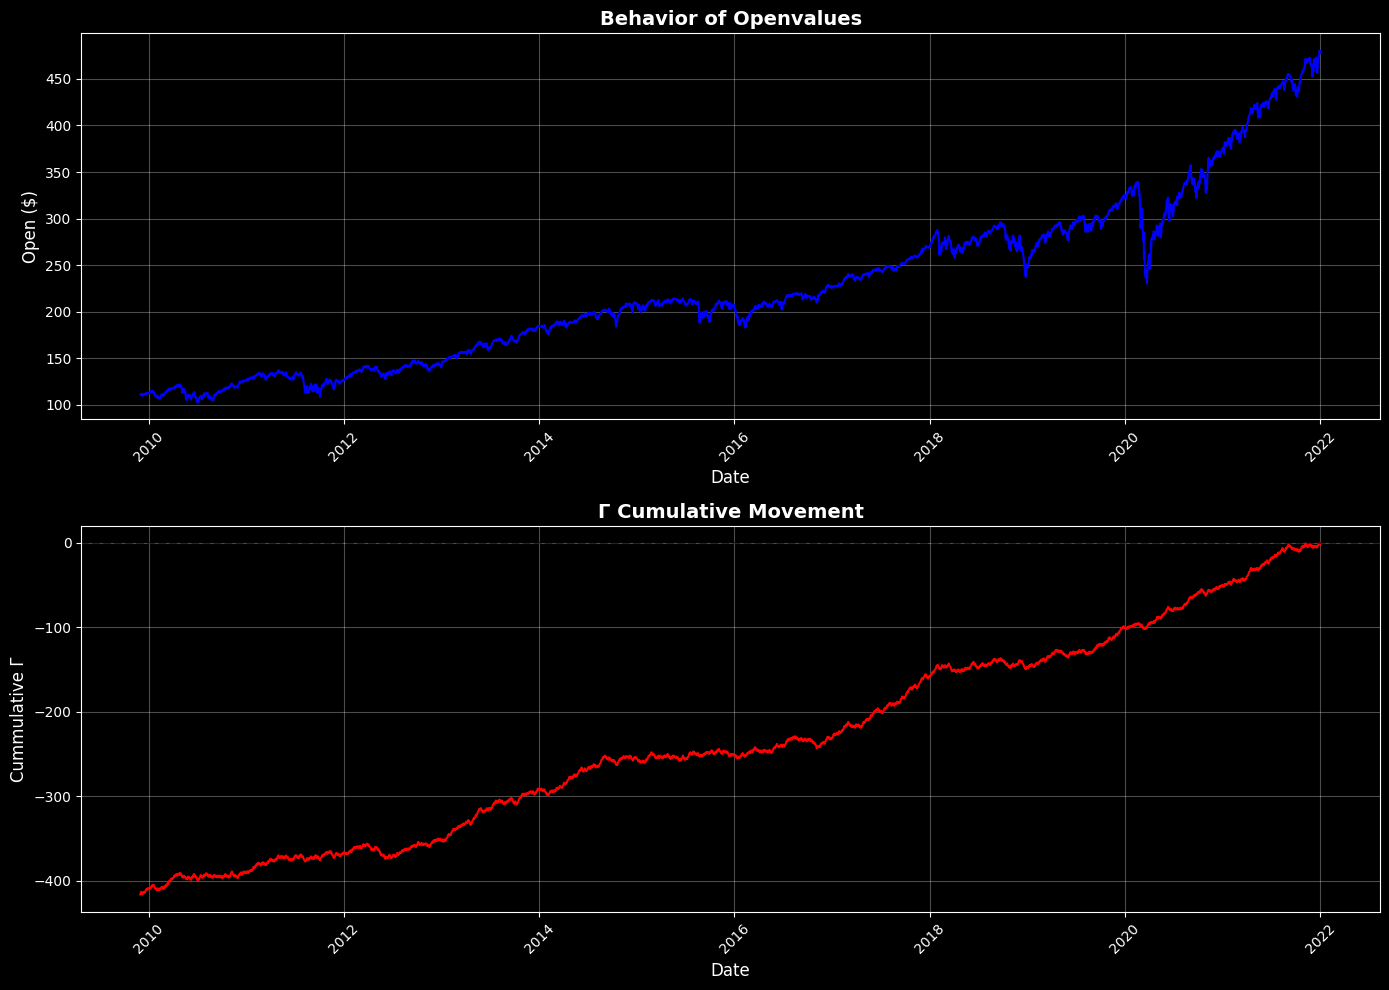

In [5]:
df['Cumulative_Gamma'] = df['Gamma'].cumsum()
df['Date'] = pd.to_datetime(df['Date'])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(df['Date'], df['Open'], linewidth=1.5, color='blue')
ax1.set_title('Behavior of Openvalues', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Open ($)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

ax2.plot(df['Date'], df['Cumulative_Gamma'], linewidth=1.5, color='red')
ax2.set_title('Γ Cumulative Movement', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cummulative Γ', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('step3_plots.png', dpi=300, bbox_inches='tight')